In [5]:
import collocation_WEB as cWEB
import numpy as np
import matplotlib.pyplot as plt
import importlib
import Geomertry
import PDE_testcases
import mesh
import network_defs as netdefs
import torch
torch.set_default_dtype(torch.float64)

In [32]:
model = Geomertry.AnaliticalDistance_CASE8()
res = cWEB.run_example(model=model, n=4, H=100, function_case=8, verbose=True, plot_mode='2d')

WEB-Spline Collocation: degree=4, H=100, domain={'x1': -4.0, 'x2': 4.0, 'y1': -3.0, 'y2': 3.0}, case=8
Domain transform: [0,1]² → [-4.0,4.0]×[-3.0,3.0]
Laplacian factors in grid coords: ax=1/scale_x^2=1.562e-02, ay=1/scale_y^2=2.778e-02
Classification...
  Inner B-splines: 7204
  Outer B-splines: 1032
  Inner element arrays: 6172
Building extension matrix...
  Extension matrix: 7204 x 1032, nnz = 10300
Assembling collocation matrix...


TypeError: 'NoneType' object is not callable

In [47]:
import network_defs as netdefs
import PDE_testcases
import inhomogenous_boundary as ihbnd
importlib.reload(cWEB)
importlib.reload(ihbnd)
model_MS = netdefs.load_test_model("SIREN_pentagon_MMSDF", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model = ihbnd.sharp_min_distance_function(model_MS)
n = 2
H = 20
function_case = 11
verbose = True
show_plot = True
CD = None
solve_method  = "auto"
dense_threshold = 2000
plot_mode = "3d"


global DOMAIN

active_case = 11
domain = PDE_testcases.get_domain_for_case(active_case)
DOMAIN = PDE_testcases.DOMAIN


if verbose:
    print("=" * 60)
    print(f"WEB-Spline Collocation: degree={n}, H={H}, domain={DOMAIN}, case={active_case}")
    print("=" * 60)

wfct = cWEB.NeuralWeightFunction(model=model, domain=DOMAIN)
transformer = cWEB.create_domain_transformer(DOMAIN)

if CD is None:
    CD = cWEB.compute_collocation_data(n, J_MAX=16)

Uxy, xB, yB, con, dim_sys, rtimes = cWEB.collocation_2d(
    n,
    H,
    wfct,
    f=PDE_testcases.load_function_vectorized,
    CD=CD,
    verbose=verbose,
    domain=DOMAIN,
    solve_method=solve_method,
    dense_threshold=dense_threshold,
    model=model_MS,
    function_case=active_case
)

if Uxy is None:
    print("Solver failed!")
    raise RuntimeError("Collocation solver failed.")



WEB-Spline Collocation: degree=2, H=20, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 271
  Outer B-splines: 129
  Inner element arrays: 111
Building extension matrix...
  Extension matrix: 271 x 129, nnz = 531
Assembling collocation matrix...
line 1081 -> fiy this later!!! 
Solving linear system...
Estimating condition number...
  System dimension: 271
  Condition number: 1.38e+05
Evaluating solution...


WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23789
  Outer B-splines: 1500
  Inner element arrays: 22327
Building extension matrix...
  Extension matrix: 23789 x 1500, nnz = 14240
Assembling collocation matrix...
line 1081 -> fiy this later!!! 
Solving linear system...
  System dimension: 23789
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 3.551925e-01
  Relative L2 error:  3.090271e+01
  Mean absolute error: 1.678747e-01
  Absolute L-inf error: 3.551925e-01
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23789

Timing:
  Classification/Assembly: 12.101s
  Extension:               0.170s
  Solution:                1.058s
  Total:                   13.329s


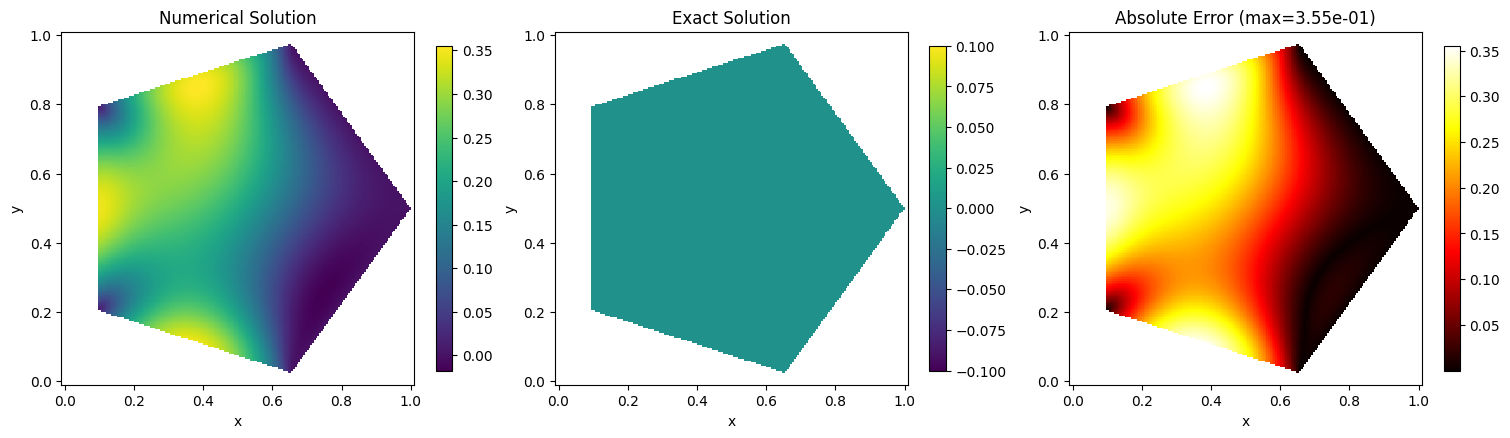

In [6]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(Geomertry)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Use the scalar adapter for run_example, and keep the 5-output model for model_ms.
model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
#model_MS = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=0.0)
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
#model = ihbnd.sharp_min_distance_function_hollig(model=model_MS, delta = 0.05, gamma= 3)
model = ihbnd.R_func_min(model=model_MS)
# Enable return_coefficients=True so we can use the result for pointwise evaluation.
res = cWEB.run_example(
    model=model,
    n=4,
    H=200,
    function_case=11,
    verbose=True,
    plot_mode='2d',
    return_coefficients=True,
    model_ms=model_MS,
)

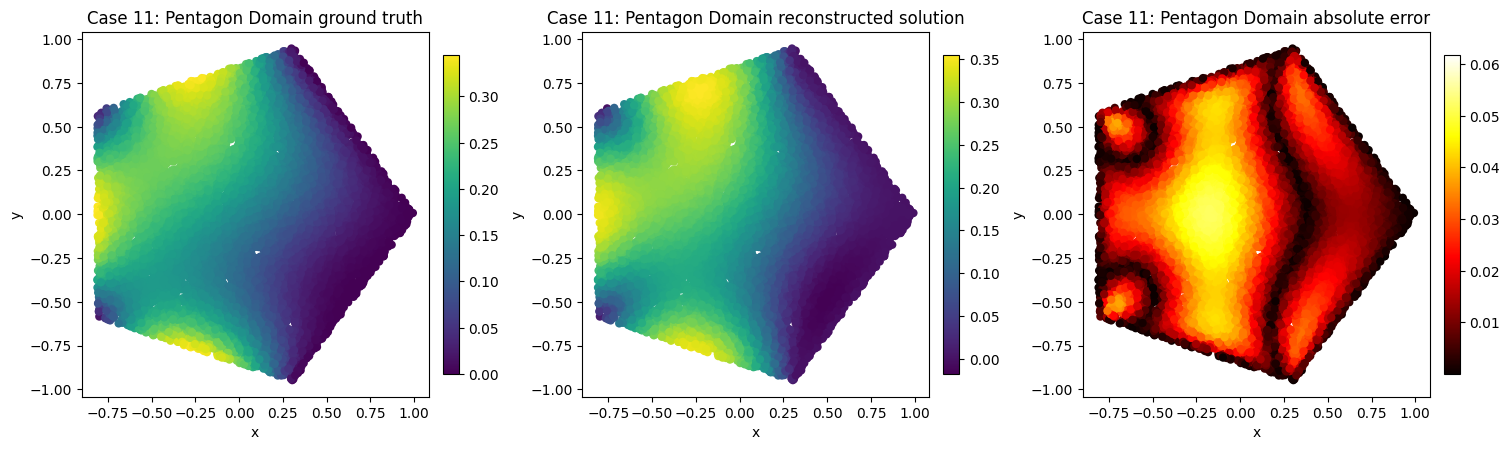


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [-0.017421, 0.355107]
  Max absolute error: 6.181113e-02
  Mean absolute error: 2.213091e-02


In [7]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")

Inhomogeneous samples: 10000 points
Homogeneous samples:    10000 points
Max abs difference: 3.454718e-01
Mean abs difference: 1.899605e-02


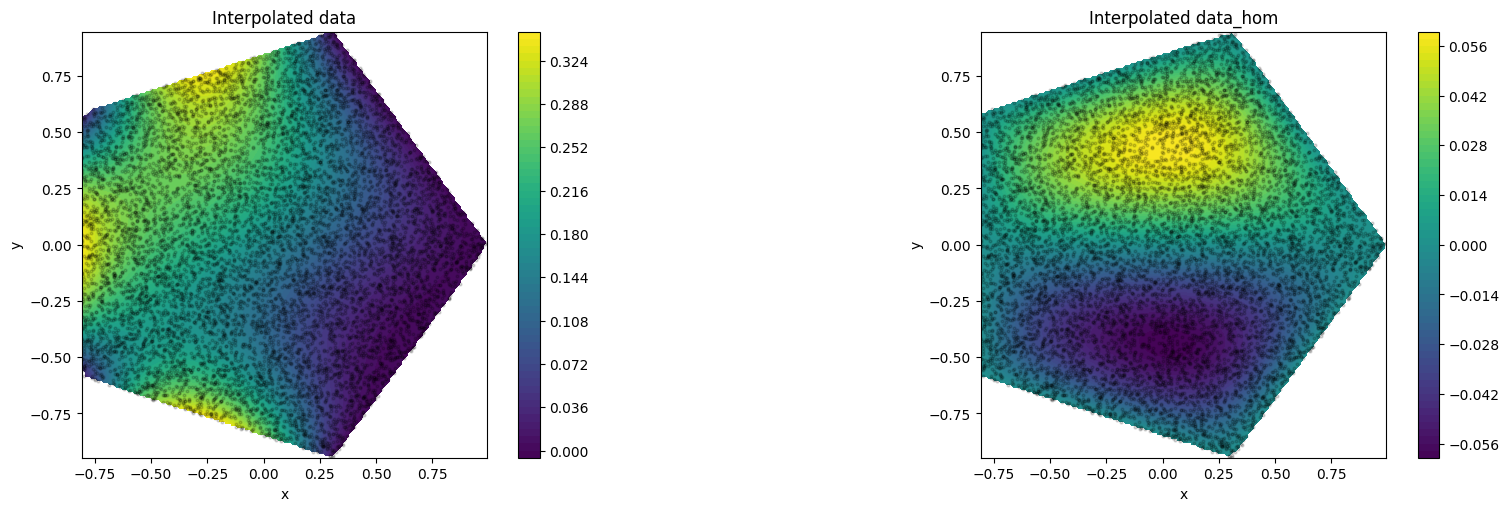

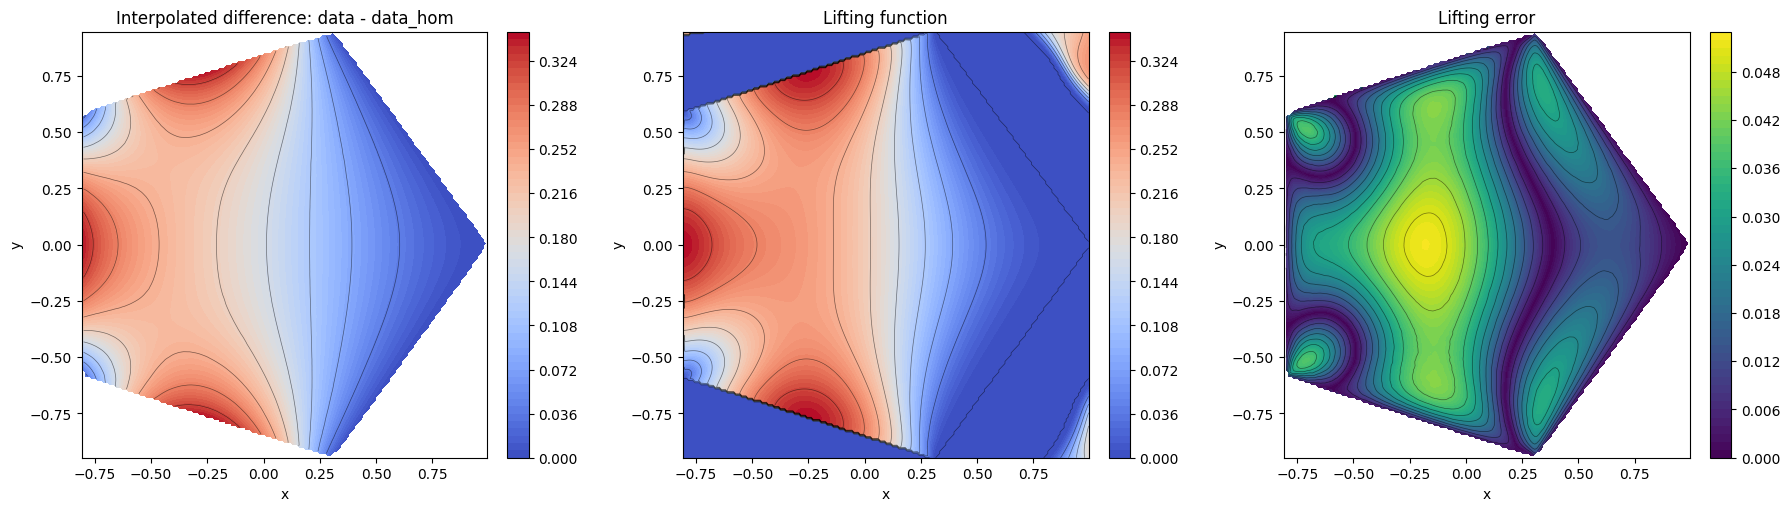

In [8]:
# Interpolate the scattered samples and compare the inhomogeneous and homogeneous fields
from pathlib import Path
from matplotlib.tri import LinearTriInterpolator, Triangulation
importlib.reload(ihbnd)
def find_csv(filename):
    matches = sorted(Path.cwd().rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {Path.cwd()}")
    return matches[0]

csv_file_inh = find_csv("poisson_samples_inhom_1_e_3.csv")
data = np.genfromtxt(csv_file_inh, delimiter=",", names=True)

csv_file_hom = find_csv("poisson_samples_hom_1_e_3.csv")
data_hom = np.genfromtxt(csv_file_hom, delimiter=",", names=True)

if data.size == 0:
    raise ValueError(f"No samples found in {csv_file_inh}")
if data_hom.size == 0:
    raise ValueError(f"No samples found in {csv_file_hom}")

pts_x = np.asarray(data["x"], dtype=np.float64).ravel()
pts_y = np.asarray(data["y"], dtype=np.float64).ravel()
gt = np.asarray(data["u"], dtype=np.float64).ravel()

pts_x_hom = np.asarray(data_hom["x"], dtype=np.float64).ravel()
pts_y_hom = np.asarray(data_hom["y"], dtype=np.float64).ravel()
gt_hom = np.asarray(data_hom["u"], dtype=np.float64).ravel()

wfct_phys = cWEB.NeuralWeightFunction(model=model, domain=None)

x_min = min(pts_x.min(), pts_x_hom.min())
x_max = max(pts_x.max(), pts_x_hom.max())
y_min = min(pts_y.min(), pts_y_hom.min())
y_max = max(pts_y.max(), pts_y_hom.max())
grid_x = np.linspace(x_min, x_max, 200)
grid_y = np.linspace(y_min, y_max, 200)
X, Y = np.meshgrid(grid_x, grid_y)

def interpolate_to_grid(x, y, values):
    triangulation = Triangulation(x, y)
    interpolator = LinearTriInterpolator(triangulation, values)
    return interpolator(X, Y)

U_inh = interpolate_to_grid(pts_x, pts_y, gt)
U_hom = interpolate_to_grid(pts_x_hom, pts_y_hom, gt_hom)
U_diff = U_inh - U_hom
#create stacked grid points for lifting function evaluation
x_flattened = np.ravel(X)
y_flattened = np.ravel(Y)
lifting = ihbnd.get_lifting(model=model_MS,function_case = 11, num_sides=5, points = torch.tensor(np.column_stack((x_flattened, y_flattened)), dtype=torch.float64)).detach().cpu().numpy().reshape(X.shape)
#lifting = ihbnd.get_lifting_R(model=model_MS,function_case = 11, num_sides=5, points = torch.tensor(np.column_stack((x_flattened, y_flattened)), dtype=torch.float64)).detach().cpu().numpy().reshape(X.shape)
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plots = [
    (U_inh, "Interpolated data", "viridis"),
    (U_hom, "Interpolated data_hom", "viridis"),
    
]

lift_error = np.abs(lifting - U_diff)
plots2 = [
    (U_diff, "Interpolated difference: data - data_hom", "coolwarm"),
    (lifting, "Lifting function", "coolwarm"),
    (lift_error, "Lifting error", "viridis"),
]

for ax, (values, title, cmap) in zip(axes, plots):
    values = np.ma.masked_invalid(values)
    im = ax.contourf(X, Y, values, levels=60, cmap=cmap)
    ax.scatter(pts_x, pts_y, s=4, c='k', alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax, (values, title, cmap) in zip(axes2, plots2):
    values = np.ma.masked_invalid(values)
    im = ax.contourf(X, Y, values, levels=60, cmap=cmap)
    #ax.scatter(pts_x, pts_y, s=4, c='k', alpha=0.15)
    ax.contour(X, Y, values, levels=10, colors='k', linewidths=0.5, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(f"Inhomogeneous samples: {len(gt)} points")
print(f"Homogeneous samples:    {len(gt_hom)} points")
print(f"Max abs difference: {np.nanmax(np.abs(np.asarray(lift_error))):.6e}")
print(f"Mean abs difference: {np.nanmean(np.abs(np.asarray(lift_error))):.6e}")

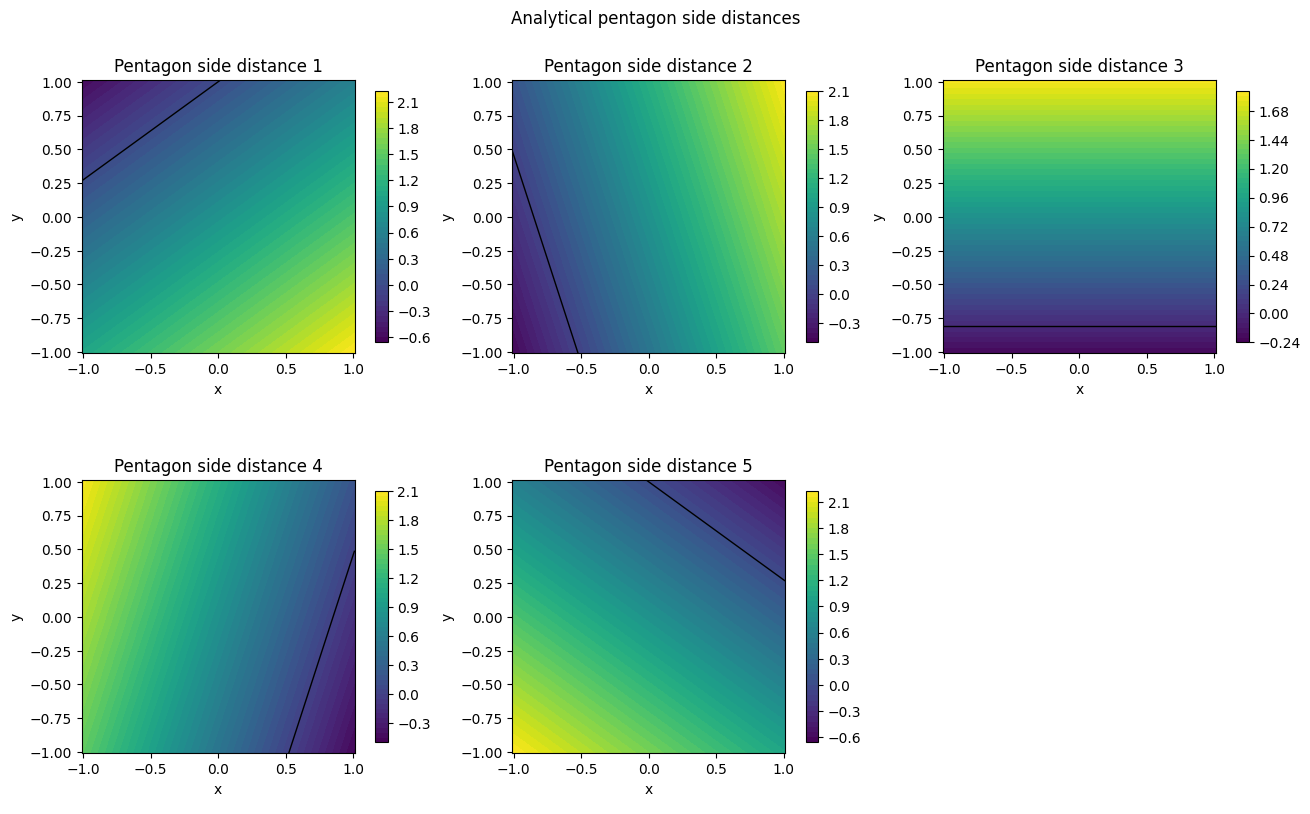

Lifting values: tensor([0., 0., 0.,  ..., 0., 0., 0.])


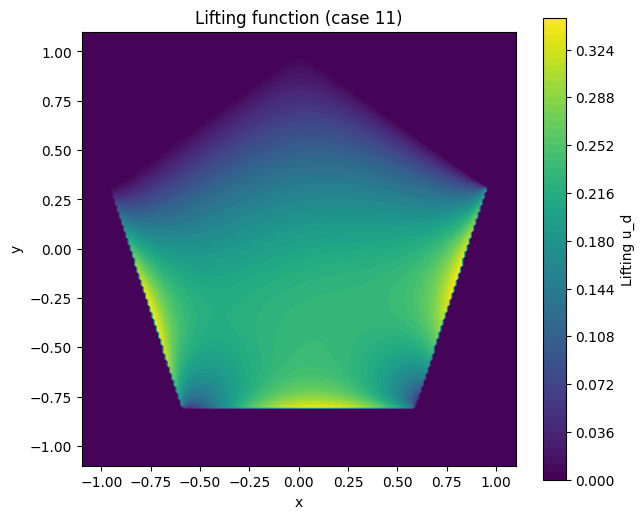

Analytical pentagon model output shape: (1, 5)
Lifting range: [0.000000, 0.344709]


In [6]:
import importlib
import numpy as np
import torch
import Geomertry
import inhomogenous_boundary as ihbnd

importlib.reload(Geomertry)
importlib.reload(ihbnd)

# Analytical 5-output pentagon distance model.
# Radius=1.0 matches the pentagon geometry assumed by the inhomogeneous boundary helper.
model = Geomertry.AnaliticalDistancePentagon_SideDistances(radius=1.0, rotation=np.pi / 2)

# Visualize the five signed distances, one per side.
model.create_contour_plot(resolution=200)

# Example use in the inhomogeneous boundary workflow.
# The model returns 5 outputs, so it can be plugged directly into the lifting code.
X, Y, U_lift = ihbnd.plot_lifting_function(
    model=model,
    function_case=11,
    num_sides=5,
    N=200,
    extent=(-1.1, 1.1, -1.1, 1.1),
    cmap='viridis',
    show=True,
)

print(f'Analytical pentagon model output shape: {tuple(model(torch.tensor([[0.0, 0.0]], dtype=torch.float64)).shape)}')
print(f'Lifting range: [{U_lift.min():.6f}, {U_lift.max():.6f}]')

Lifting values: tensor([0.2034, 0.2028, 0.2021,  ..., 0.0000, 0.0000, 0.0000])
Max abs difference: 2.240262e+122
Mean abs difference: 1.080177e+118


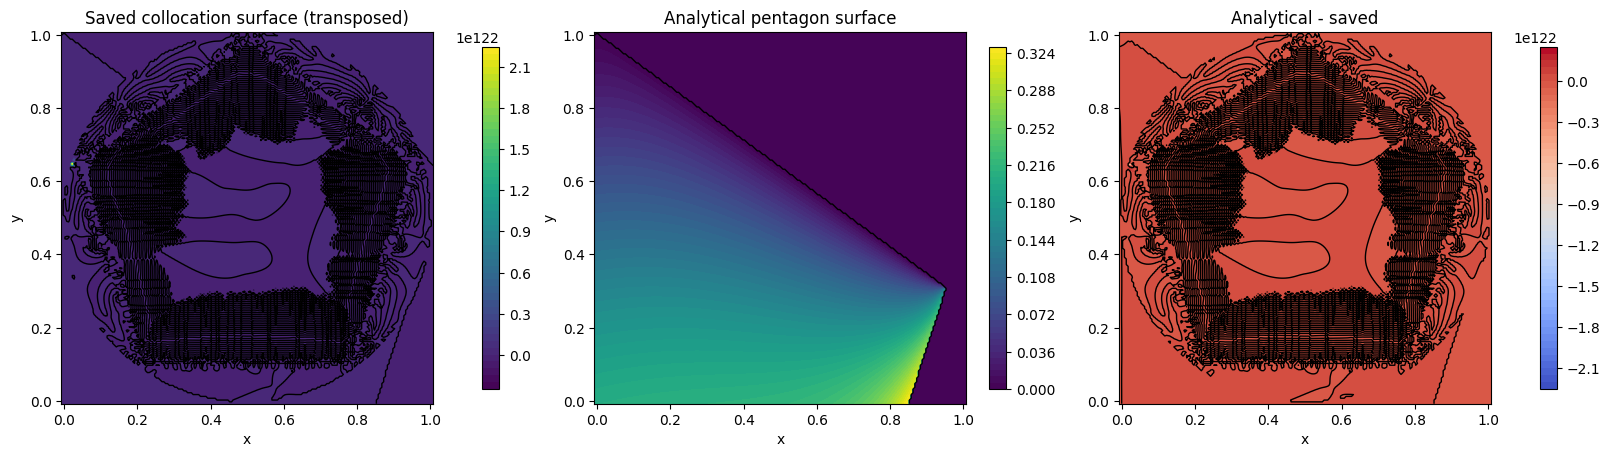

In [7]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch
import collocation_WEB as cWEB
import network_defs as netdefs
import PDE_testcases
import inhomogenous_boundary as ihbnd

importlib.reload(cWEB)
importlib.reload(PDE_testcases)
importlib.reload(ihbnd)

# Compare the analytical pentagon lifting surface against the saved collocation surface.
# The saved surface is stored as res['Uxy'], but its x/y orientation is swapped relative to
# the grid used by the analytical lift, so we transpose it before plotting or differencing.
if 'res' not in globals():
    model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_02", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
    model_saved = ihbnd.smooth_min_preserve_zero_distance_function_2side(model=model_MS, k=20)
    res = cWEB.run_example(model=model_saved, n=4, H=200, function_case=11, verbose=True, plot_mode='2d', return_coefficients=True, model_ms=model_MS)

reference = np.asarray(res['Uxy']).T
ref_x = np.asarray(res['xB'])
ref_y = np.asarray(res['yB'])
if reference.shape != ref_x.shape or reference.shape != ref_y.shape:
    raise ValueError(
        f"Shape mismatch: reference={reference.shape}, xB={ref_x.shape}, yB={ref_y.shape}"
    )

# Re-evaluate the analytical model on the exact same grid used by the saved surface.
ref_points = torch.tensor(np.column_stack([ref_x.ravel(), ref_y.ravel()]), dtype=torch.float64)
with torch.no_grad():
    analytical_ref = ihbnd.get_lifting(model=model, function_case=11, num_sides=5, points=ref_points).detach().cpu().numpy().reshape(ref_x.shape)

diff = analytical_ref - reference

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
plots = [
    (reference, 'Saved collocation surface (transposed)'),
    (analytical_ref, 'Analytical pentagon surface'),
    (diff, 'Analytical - saved', 'coolwarm'),
]

for ax, plot in zip(axes, plots):
    if len(plot) == 2:
        values, title = plot
        cmap = 'viridis'
    else:
        values, title, cmap = plot
    im = ax.contourf(ref_x, ref_y, values, levels=60, cmap=cmap)
    ax.contour(ref_x, ref_y, values, levels=[0], colors='k', linewidths=1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(f'Max abs difference: {np.abs(diff).max():.6e}')
print(f'Mean abs difference: {np.abs(diff).mean():.6e}')